# Regression: Drug Consumption Dataset

**Dataset:** Drug Consumption (UCI Machine Learning Repository)
**Author:** *Daniel Marquino Pérez*

---

## 1. Dataset Description and Regression Context

The *Drug Consumption* dataset contains **1,884 respondents** described by 31 features: 5 demographic variables, 7 personality scores (z-scaled), and 19 drug-consumption columns on the ordinal scale CL0-CL6.

The seven personality scores (Nscore, Escore, Oscore, AScore, Cscore, Impulsive, SS) are the only genuinely continuous features in the dataset, so they are the natural candidates for a regression analysis. Two findings from the exploratory data analysis motivate the task:

1. **Sensation Seeking (SS) declines monotonically with age**.
2. The personality scores are mutually correlated: in particular Impulsivity and Sensation Seeking visibly move together.

**Regression task.** Sensation Seeking is chosen as the dependent variable: it was the most informative personality trait in both previous phases (strongest association with substance use in the EDA, top-ranked feature in the classification), so understanding *what explains SS itself* completes the project.

**Models compared** (each answering a different question):

1. **Simple linear regression** - `SS ~ Impulsive`: how much does the single strongest correlate explain?
2. **Multiple linear regression** - `SS ~ remaining six personality scores + Age`: how much do all traits together explain, and what is each one's contribution holding the others constant?
3. **Polynomial (generalised linear) regression** - `SS ~ Age`: is the age-related decline of SS linear or curved?

---
## 2. Setup: Import Packages

In [2]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   # Graphics package
from IPython.display import display   # Render result tables as native DataFrames (no extra dependency)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset directly from github URL
URL = 'https://raw.githubusercontent.com/maarqui/drug-consumption-analysis/main/Drug_Consumption.csv'
myData = pd.read_csv(URL)

# Remove the ID column - it is a row identifier with no analytical value
myData = myData.drop(columns=['ID'])

print('Dataset loaded: %d rows x %d columns' % myData.shape)

Dataset loaded: 1884 rows x 31 columns


In [3]:
# Continuous personality scores and ordinal Age encoding
personality_scores = ['Nscore', 'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS']

# Ordinal mapping for Age (youngest -> oldest), as in the classification phase
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_mapping = {label: i for i, label in enumerate(age_order)}
myData['Age_ord'] = myData['Age'].map(age_mapping)

print('Continuous features (n=%d):' % len(personality_scores), personality_scores)
print('Ordinal age encoding     :', age_mapping)

Continuous features (n=7): ['Nscore', 'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'SS']
Ordinal age encoding     : {'18-24': 0, '25-34': 1, '35-44': 2, '45-54': 3, '55-64': 4, '65+': 5}


---
## 3. Correlation Analysis

Before fitting any model, the pairwise Pearson correlations between the seven personality scores and Age are examined. `Age_ord` is an ordinal variable treated as quasi-interval (equally spaced ranks), its correlations are approximate but adequate for screening.

This helps to answer question: *which continuous features are interesting, and which correlations exist between them?*

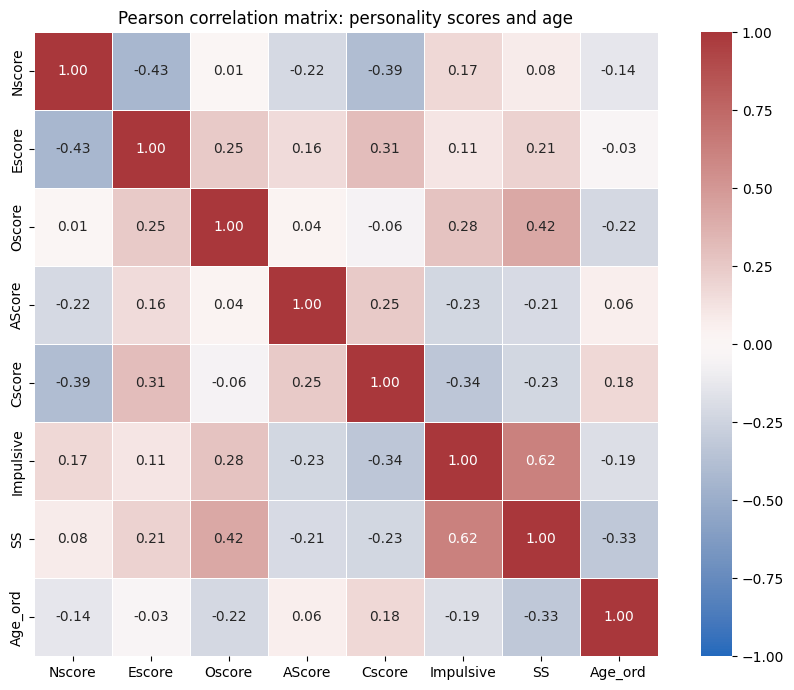

In [4]:
# Correlation matrix of the continuous features (plus ordinal Age)
import seaborn as sns

continuous_features = personality_scores + ['Age_ord']
corr_matrix = myData[continuous_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='vlag', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson correlation matrix: personality scores and age')
plt.tight_layout()

In [5]:
# Strongest correlated pairs, ranked by absolute correlation
pairs = []
for i in range(len(continuous_features)):
    for j in range(i + 1, len(continuous_features)):
        r = corr_matrix.iloc[i, j]
        pairs.append([continuous_features[i], continuous_features[j], r])
pairs.sort(key=lambda row: -abs(row[2]))

corr_pairs_df = pd.DataFrame(pairs[:6], columns=['Feature 1', 'Feature 2', 'Pearson r']).round(3)
print('Top 6 correlated feature pairs:')
display(corr_pairs_df)

Top 6 correlated feature pairs:


,Feature 1,Feature 2,Pearson r
0,Impulsive,SS,0.623
1,Nscore,Escore,-0.431
2,Oscore,SS,0.422
3,Nscore,Cscore,-0.391
4,Cscore,Impulsive,-0.335
5,SS,Age_ord,-0.327


**Interpretation.** Three correlations stand out:

- **Impulsive - SS (r = 0.623)**: by far the strongest pair, a strong positive association.
- **Oscore - SS (r = 0.422)**: openness to experience also rises with Sensation Seeking.
- **SS - Age (r = -0.327)**: the monotonic decline already observed graphically in the EDA.

SS participates in the three strongest relationships of interest: it is the *hub* of the correlation structure, which supports its choice as dependent variable.

**Could the Impulsive-SS correlation be spurious?** (*a correlation is spurious when a third variable drives both*). 

The most probable candidate in the data is Age as both traits decline with age. The partial correlation controlling for Age tests this directly:

In [6]:
# Partial correlation Impulsive-SS controlling for Age
r_xy = corr_matrix.loc['Impulsive', 'SS']
r_xz = corr_matrix.loc['Impulsive', 'Age_ord']
r_yz = corr_matrix.loc['SS', 'Age_ord']

r_partial = (r_xy - r_xz * r_yz) / np.sqrt((1 - r_xz**2) * (1 - r_yz**2))

print('Pearson r (Impulsive, SS)       : %.3f' % r_xy)
print('Partial r (Impulsive, SS | Age) : %.3f' % r_partial)

Pearson r (Impulsive, SS)       : 0.623
Partial r (Impulsive, SS | Age) : 0.606


The partial correlation (*0.606*) is almost identical to the raw correlation (*0.623*): the Impulsive-SS relationship is **not** explained away by age, so a spurious correlation through age can be excluded.

A conceptual caveat remains: Impulsive (BIS-11) and SS (ImpSS) both originate from the impulsivity domain of psychology, so a genuine association between them is *expected by construction*. The regression below quantifies a real and stable relationship, but it partly reflects overlap between two related psychological variables rather than a causal mechanism.

---
## 4. Cross-Validation Setup and Helper Function

As in the classification phase, **5-fold cross-validation** is used so that every model is evaluated on data it was not fitted on. Plain `KFold` replaces `StratifiedKFold` because the target is continuous, there are no classes to stratify. The same `random_state` keeps the folds reproducible.

The evaluation procedure (cross-validated R², RMSE and MAE from out-of-fold predictions) is identical for all three models, so it is defined once as a helper function.

In [7]:
# 5-fold cross-validation strategy (plain KFold: the target is continuous)
N = 5
cv = KFold(n_splits=N, shuffle=True, random_state=42)


def evaluate_regression(model, X_data, y_data, cv, name):
    '''Run 5-fold CV and print R^2 (mean +/- std), RMSE and MAE from out-of-fold predictions.'''
    r2_scores = cross_val_score(model, X_data, y_data, cv=cv, scoring='r2')
    predicted = cross_val_predict(model, X_data, y_data, cv=cv)
    rmse = np.sqrt(mean_squared_error(y_data, predicted))
    mae  = mean_absolute_error(y_data, predicted)
    print('%s' % name)
    print('  CV R^2  : %.4f +/- %.4f' % (r2_scores.mean(), r2_scores.std()))
    print('  CV RMSE : %.4f' % rmse)
    print('  CV MAE  : %.4f' % mae)
    return r2_scores, predicted, rmse, mae


print('Cross-validation strategy : %s' % type(cv).__name__)
print('Number of folds           : %d' % cv.get_n_splits())

Cross-validation strategy : KFold
Number of folds           : 5


---
## 5. Model 1: Simple Linear Regression - SS ~ Impulsive

The simple linear regression on the single strongest correlate serves as the **baseline model**: one coefficient, directly interpretable, and a reference point against which the multiple regression must justify its additional complexity.

In [8]:
# Fit the simple linear regression on the full data
y = myData['SS'].values
X_simple = myData[['Impulsive']]

linreg_simple = LinearRegression()
linreg_simple.fit(X_simple, y)

print('Regression equation : SS = %.4f + %.4f * Impulsive' %
      (linreg_simple.intercept_, linreg_simple.coef_[0]))
print('R^2 (full data)     : %.4f' % linreg_simple.score(X_simple, y))
print()

r2_simple, pred_simple, rmse_simple, mae_simple = evaluate_regression(
    linreg_simple, X_simple, y, cv, 'Simple linear regression (SS ~ Impulsive)')

Regression equation : SS = -0.0073 + 0.6290 * Impulsive
R^2 (full data)     : 0.3884

Simple linear regression (SS ~ Impulsive)
  CV R^2  : 0.3846 +/- 0.0288
  CV RMSE : 0.7544
  CV MAE  : 0.5973


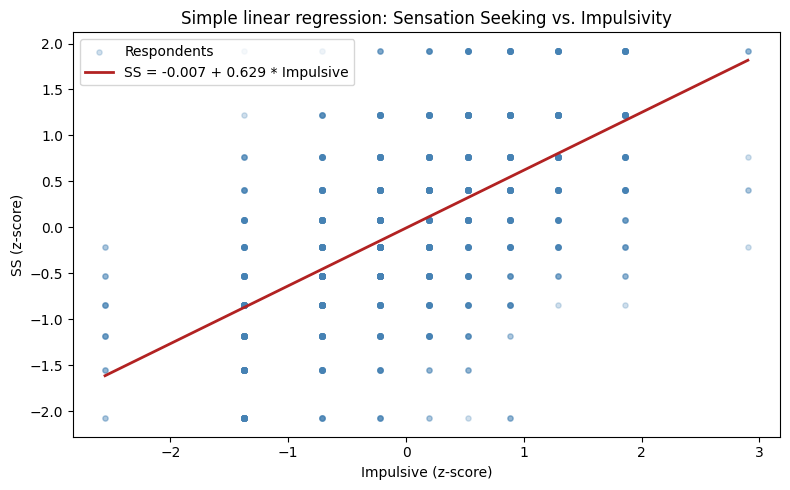

In [9]:
# Scatter plot with the fitted regression line
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(myData['Impulsive'], y, s=14, alpha=0.25, color='steelblue', label='Respondents')

x_line = np.linspace(myData['Impulsive'].min(), myData['Impulsive'].max(), 100)
ax.plot(x_line, linreg_simple.intercept_ + linreg_simple.coef_[0] * x_line,
        color='firebrick', linewidth=2,
        label='SS = %.3f + %.3f * Impulsive' % (linreg_simple.intercept_, linreg_simple.coef_[0]))

ax.set_title('Simple linear regression: Sensation Seeking vs. Impulsivity')
ax.set_xlabel('Impulsive (z-score)')
ax.set_ylabel('SS (z-score)')
ax.legend()
plt.tight_layout()

Residual mean : -0.0000
Residual std  : 0.7534


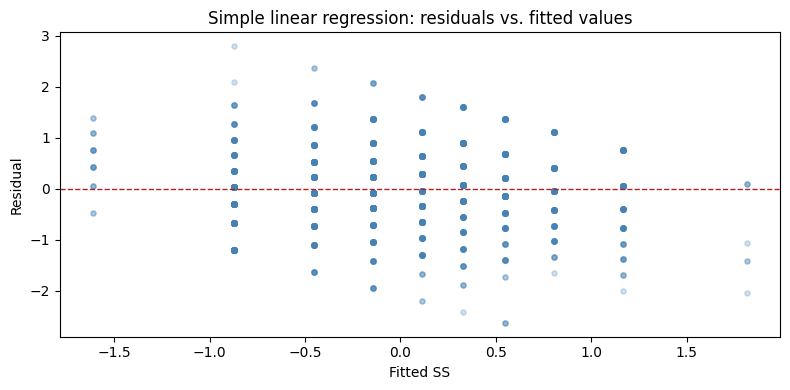

In [10]:
# Residual plot: residuals vs. fitted values
fitted    = linreg_simple.predict(X_simple)
residuals = y - fitted

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(fitted, residuals, s=14, alpha=0.25, color='steelblue')
ax.axhline(0, color='firebrick', linestyle='--', linewidth=1)
ax.set_title('Simple linear regression: residuals vs. fitted values')
ax.set_xlabel('Fitted SS')
ax.set_ylabel('Residual')
plt.tight_layout()

print('Residual mean : %.4f' % residuals.mean())
print('Residual std  : %.4f' % residuals.std())

**Interpretation:** The slope of **0.629** means that respondents who score one standard deviation higher on Impulsivity score on average 0.63 standard deviations higher on Sensation Seeking. The model explains **R² ≈ 0.39** of the SS variance, and the cross-validated value (0.385 ± 0.029) is nearly identical, a one-parameter model cannot overfit n = 1,884 observations.

Two visual observations:

- The points form **vertical bands** because Impulsive, although z-scaled, was measured on a discrete instrument (BIS-11) and takes only a small number of distinct values.
- The residuals are centred on zero with no funnel shape or curvature, so the linear form is adequate. The remaining scatter (residual std ≈ 0.75) is simply variance that Impulsivity alone cannot explain.

---
## 6. Model 2: Multiple Linear Regression - SS ~ Personality + Age

The correlation analysis showed that SS is related not only to Impulsivity but also to Openness, Age, Agreeableness and Conscientiousness. Multiple linear regression includes all of these simultaneously, which serves two purposes:

1. **Better prediction** - pooling all available signal.
2. **Adjusted interpretation**: each coefficient measures the contribution of one feature *holding all others constant*, which a set of pairwise correlations cannot do.

The predictors are the six remaining personality scores plus ordinal Age. The demographic nominal variables (Country, Ethnicity, Gender) are deliberately excluded: the research question concerns the structure *within* the personality profile, and the classification phase showed that Country mainly acts as a sampling-bias shortcut.

In [11]:
# Fit the multiple linear regression
features_multiple = ['Nscore', 'Escore', 'Oscore', 'AScore', 'Cscore', 'Impulsive', 'Age_ord']
X_multiple = myData[features_multiple]

linreg_multiple = LinearRegression()
linreg_multiple.fit(X_multiple, y)

# Coefficient table
coef_rows = list(zip(features_multiple, linreg_multiple.coef_))
coef_rows.append(('(Intercept)', linreg_multiple.intercept_))
coef_df = pd.DataFrame(coef_rows, columns=['Feature', 'Coefficient']).round(4)
display(coef_df)

# R^2 and adjusted R^2 on the full data
r2_full = linreg_multiple.score(X_multiple, y)
n_obs, n_feat = X_multiple.shape
r2_adjusted = 1 - (1 - r2_full) * (n_obs - 1) / (n_obs - n_feat - 1)
print()
print('R^2 (full data)     : %.4f' % r2_full)
print('Adjusted R^2        : %.4f' % r2_adjusted)
print()

r2_multiple, pred_multiple, rmse_multiple, mae_multiple = evaluate_regression(
    linreg_multiple, X_multiple, y, cv, 'Multiple linear regression (7 predictors)')

,Feature,Coefficient
0,Nscore,-0.0193
1,Escore,0.1113
2,Oscore,0.2165
3,AScore,-0.1045
4,Cscore,-0.0398
5,Impulsive,0.4850
6,Age_ord,-0.1306
7,(Intercept),0.1695



R^2 (full data)     : 0.5051
Adjusted R^2        : 0.5033

Multiple linear regression (7 predictors)
  CV R^2  : 0.4996 +/- 0.0317
  CV RMSE : 0.6797
  CV MAE  : 0.5370


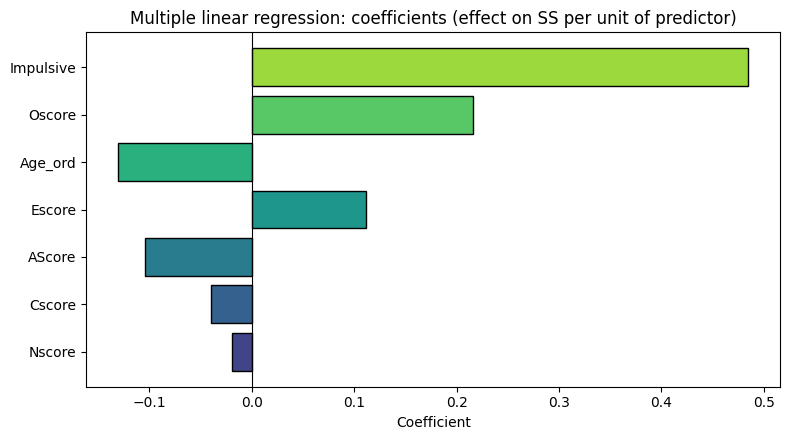

In [13]:
# Coefficient bar chart, sorted by absolute size
sorted_pairs = sorted(zip(features_multiple, linreg_multiple.coef_), key=lambda t: abs(t[1]))
sorted_names = [name for name, _ in sorted_pairs]
sorted_coefs = [coef for _, coef in sorted_pairs]

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(sorted_names)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(sorted_names, sorted_coefs, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Multiple linear regression: coefficients (effect on SS per unit of predictor)')
ax.set_xlabel('Coefficient')
plt.tight_layout()

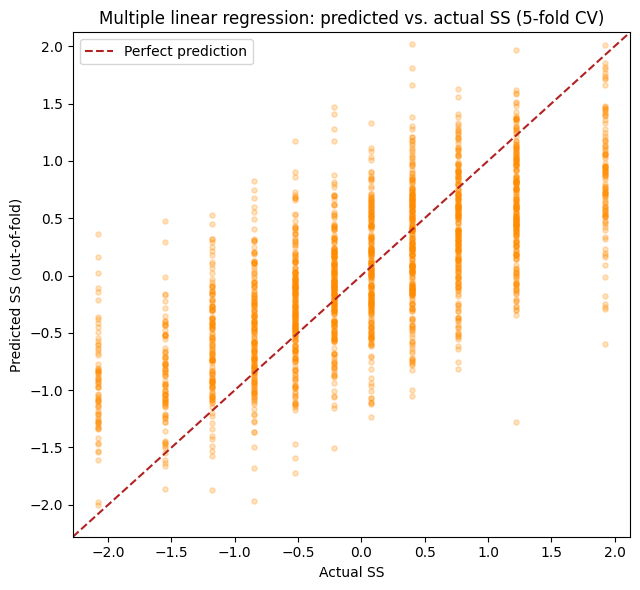

In [14]:
# Predicted vs. actual SS (out-of-fold predictions from the 5-fold CV)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y, pred_multiple, s=14, alpha=0.25, color='darkorange')

lims = [y.min() - 0.2, y.max() + 0.2]
ax.plot(lims, lims, color='firebrick', linestyle='--', linewidth=1.5, label='Perfect prediction')

ax.set_title('Multiple linear regression: predicted vs. actual SS (5-fold CV)')
ax.set_xlabel('Actual SS')
ax.set_ylabel('Predicted SS (out-of-fold)')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
plt.tight_layout()

**Interpretation:** The multiple regression lifts the explained variance from 0.39 to **R² ≈ 0.51** (adjusted 0.503, cross-validated 0.500 ± 0.032). The coefficients adjusted for all other predictors are:

- **Impulsive (+0.485)** remains the dominant predictor, although its coefficient shrinks from 0.629 in the simple model, part of its raw effect was shared with Openness and Age.
- **Oscore (+0.217)** and **Escore (+0.111)** add genuine independent signal: open and extraverted respondents seek more sensations *at the same impulsivity level*.
- **Age (-0.131 per age bracket)** confirms the EDA decline as an independent effect, not an artefact of older respondents being less impulsive.
- **Nscore (-0.019)** and **Cscore (-0.040)** contribute almost nothing once the other traits are controlled, their raw correlations with SS were largely indirect.

The predicted-vs-actual plot shows the typical signature of R² ≈ 0.5: a clear positive alignment along the diagonal, but with predictions compressed toward the mean (the model rarely predicts the extreme SS values).

---
## 7. Model 3: Polynomial Regression - SS ~ Age

The third model addresses the open question from the EDA: *is the age-related decline of Sensation Seeking linear, or does it flatten out?* Polynomial regression is a **generalised linear regression**: the model stays linear in its parameters but uses polynomial basis functions of Age (Age, Age², …) as predictors, which lets it capture curvature.

Degrees 1-4 are compared by cross-validation using a manual loop, mirroring the hyperparameter search of the classification phase.

In [15]:
# Compare polynomial degrees 1-4 via 5-fold cross-validation
X_age = myData[['Age_ord']].values

degrees = [1, 2, 3, 4]
tab_degrees = []
cv_means = []

for degree in degrees:
    X_poly = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(X_age)
    model = LinearRegression()
    r2_cv = cross_val_score(model, X_poly, y, cv=cv, scoring='r2')
    model.fit(X_poly, y)
    cv_means.append(r2_cv.mean())
    tab_degrees.append([degree, '%.4f' % model.score(X_poly, y),
                        '%.4f +/- %.4f' % (r2_cv.mean(), r2_cv.std())])

degrees_df = pd.DataFrame(tab_degrees, columns=['Degree', 'R^2 (full data)', 'CV R^2'])
display(degrees_df)

,Degree,R^2 (full data),CV R^2
0,1,0.1072,0.0979 +/- 0.0412
1,2,0.1137,0.1033 +/- 0.0438
2,3,0.1157,0.1044 +/- 0.0421
3,4,0.1174,0.1054 +/- 0.0417


The cross-validated R² is essentially **flat across all degrees** (≈ 0.10-0.11): every gain beyond degree 1 is far smaller than one standard deviation of the CV scores. Following the parsimony principle, **degree 2** is retained as the final polynomial model - it is the simplest model that can at least represent curvature, and the comparison shows that nothing beyond a quadratic is supported by the data.

In [16]:
# Fit the final quadratic model
poly_degree = 2
poly_transform = PolynomialFeatures(degree=poly_degree, include_bias=False)
X_poly2 = poly_transform.fit_transform(X_age)

linreg_poly = LinearRegression()
linreg_poly.fit(X_poly2, y)

print('Quadratic model : SS = %.4f + %.4f * Age + %.4f * Age^2' %
      (linreg_poly.intercept_, linreg_poly.coef_[0], linreg_poly.coef_[1]))
print()

r2_poly, pred_poly, rmse_poly, mae_poly = evaluate_regression(
    linreg_poly, X_poly2, y, cv, 'Polynomial regression (SS ~ Age, degree 2)')

Quadratic model : SS = 0.3880 + -0.4094 * Age + 0.0465 * Age^2

Polynomial regression (SS ~ Age, degree 2)
  CV R^2  : 0.1033 +/- 0.0438
  CV RMSE : 0.9092
  CV MAE  : 0.7234


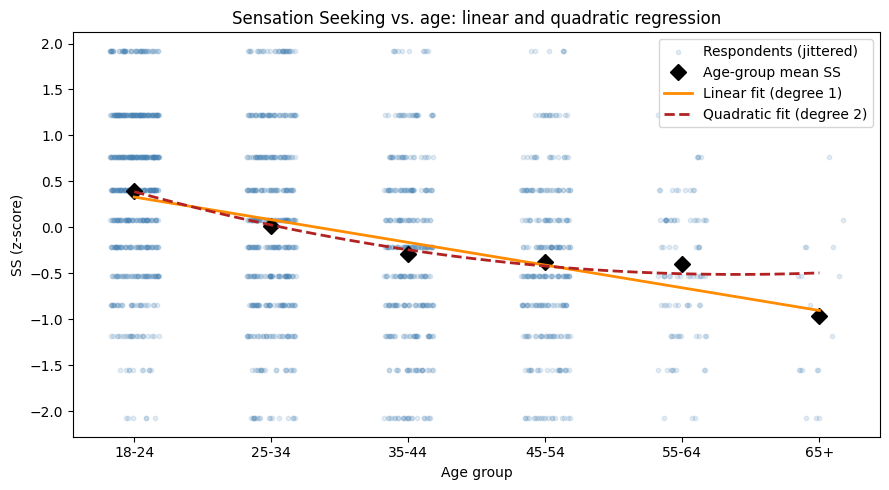

In [17]:
# Visualise: jittered scatter, age-group means, linear and quadratic fits
rng = np.random.default_rng(42)
age_jitter = myData['Age_ord'] + rng.uniform(-0.18, 0.18, len(myData))

group_means = myData.groupby('Age_ord')['SS'].mean()

x_grid = np.linspace(0, 5, 100).reshape(-1, 1)
fit_linear    = LinearRegression().fit(X_age, y)
y_grid_linear = fit_linear.predict(x_grid)
y_grid_quad   = linreg_poly.predict(poly_transform.transform(x_grid))

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(age_jitter, y, s=10, alpha=0.15, color='steelblue', label='Respondents (jittered)')
ax.plot(group_means.index, group_means.values, 'D', color='black',
        markersize=8, label='Age-group mean SS')
ax.plot(x_grid, y_grid_linear, color='darkorange', linewidth=2, label='Linear fit (degree 1)')
ax.plot(x_grid, y_grid_quad, color='firebrick', linewidth=2, linestyle='--',
        label='Quadratic fit (degree 2)')

ax.set_title('Sensation Seeking vs. age: linear and quadratic regression')
ax.set_xticks(range(len(age_order)))
ax.set_xticklabels(age_order)
ax.set_xlabel('Age group')
ax.set_ylabel('SS (z-score)')
ax.legend()
plt.tight_layout()

**Interpretation:** The linear and quadratic curves are almost indistinguishable and both track the age-group means closely: the decline of Sensation Seeking with age is **essentially linear** over the observed range, with only a hint of flattening in the two oldest groups.

At the same time, age alone explains only **≈ 10%** of the SS variance, the wide vertical scatter within every age group shows that knowing a respondent's age says little about their individual Sensation Seeking. The age effect is real and systematic at the group level, but weak at the individual level.

---
## 8. Model Comparison

The three models are compared with three complementary criteria, all computed from the same 5-fold cross-validation: **R²** (share of explained variance), **RMSE** (typical prediction error, penalising large errors) and **MAE** (typical prediction error, robust to outliers).

In [18]:
# Summary comparison table (all metrics from 5-fold CV out-of-fold predictions)
tab_comparison = [
    ['1. Simple linear (SS ~ Impulsive)',
     '%.4f +/- %.4f' % (r2_simple.mean(), r2_simple.std()),
     '%.4f' % rmse_simple, '%.4f' % mae_simple],
    ['2. Multiple linear (7 predictors)',
     '%.4f +/- %.4f' % (r2_multiple.mean(), r2_multiple.std()),
     '%.4f' % rmse_multiple, '%.4f' % mae_multiple],
    ['3. Polynomial (SS ~ Age, degree 2)',
     '%.4f +/- %.4f' % (r2_poly.mean(), r2_poly.std()),
     '%.4f' % rmse_poly, '%.4f' % mae_poly],
]

comparison_df = pd.DataFrame(tab_comparison, columns=['Model', 'CV R^2', 'CV RMSE', 'CV MAE'])
print('5-fold cross-validation results:')
display(comparison_df)

5-fold cross-validation results:


,Model,CV R^2,CV RMSE,CV MAE
0,1. Simple linear (SS ~ Impulsive),0.3846 +/- 0.0288,0.7544,0.5973
1,2. Multiple linear (7 predictors),0.4996 +/- 0.0317,0.6797,0.5370
2,"3. Polynomial (SS ~ Age, degree 2)",0.1033 +/- 0.0438,0.9092,0.7234


**The multiple linear regression is clearly the best model** on every criterion: it explains half of the SS variance (CV R² ≈ 0.50) with a typical error of 0.68 standard deviations, against 0.38 / 0.75 for the simple model and 0.10 / 0.92 for the age-only polynomial. The ranking is also informative in itself:

- Most of the explainable signal sits in **Impulsivity alone** (0.38 of the total 0.50).
- The remaining traits and age add a moderate but genuine improvement (+0.12 R²).
- Age by itself is a weak predictor, its information is largely absorbed by the personality scores in the multiple model.

---
## 9. Predictions for New Data

The two hypothetical respondents from the classification phase are reused, which makes the prediction test directly comparable across phases. In Classification their SS values were *assumed* as part of the profile design (+1.5 for the high-risk Respondent A, -1.5 for the low-risk Respondent B), here the regression models **predict** SS from the remaining traits, so the assumed values serve as a plausibility reference:

- **Respondent A**: young (18-24), high Impulsivity (+1.2), high Openness (+1.8): expected *high* SS.
- **Respondent B**: older (55-64), low Impulsivity (-1.0), low Openness (-1.0), high Conscientiousness (+0.8): expected *low* SS.

In [19]:
# Construct the two respondents (same personality profiles as in the classification phase)
respondent_A = pd.DataFrame([{
    'Nscore': 0.5, 'Escore': 0.0, 'Oscore': 1.8, 'AScore': 0.0,
    'Cscore': -0.2, 'Impulsive': 1.2, 'Age_ord': age_mapping['18-24'],
}])
respondent_B = pd.DataFrame([{
    'Nscore': -0.5, 'Escore': 0.0, 'Oscore': -1.0, 'AScore': 0.5,
    'Cscore': 0.8, 'Impulsive': -1.0, 'Age_ord': age_mapping['55-64'],
}])

# Predict SS with both linear models
tab_predictions = []
for name, row, assumed in [('Respondent A', respondent_A, 1.5),
                           ('Respondent B', respondent_B, -1.5)]:
    pred_m1 = linreg_simple.predict(row[['Impulsive']])[0]
    pred_m2 = linreg_multiple.predict(row[features_multiple])[0]
    tab_predictions.append([name, '%.3f' % pred_m1, '%.3f' % pred_m2, '%.1f' % assumed])

predictions_df = pd.DataFrame(
    tab_predictions,
    columns=['Respondent', 'Model 1 (simple)', 'Model 2 (multiple)', 'Assumed'])
display(predictions_df)
print()
print('Observed SS range in the data: %.3f to %.3f' % (y.min(), y.max()))

,Respondent,Model 1 (simple),Model 2 (multiple),Assumed
0,Respondent A,0.748,1.139,1.5
1,Respondent B,-0.636,-1.129,-1.5



Observed SS range in the data: -2.078 to 1.922


**Do the predictions make sense?** Yes, on all three checks:

1. **Direction and order are correct**: both models predict clearly positive SS for the high-risk profile and clearly negative SS for the low-risk profile.
2. **The values are plausible**: all predictions lie comfortably inside the observed SS range (-2.08 to +1.92).
3. **The attenuation is expected**: the predictions (≈ +1.14 / -1.13 for the multiple model) are pulled toward the mean relative to the assumed ±1.5. This is exactly what a regression with R² = 0.5 should do, it predicts the *expected* SS given the profile, and extreme profiles are still predicted somewhat conservatively. The multiple model also separates the two respondents more strongly than the simple model (2.27 vs. 1.38 z-score units apart), because it additionally exploits Openness and Age.

---
## 10. Summary of Key Findings

1. **Sensation Seeking is the centre of the personality correlation structure.** Its strongest correlate is Impulsivity (r = 0.623), the partial correlation controlling for age (0.606) shows this relationship is not spurious with respect to age, although the two scales share conceptual overlap from the impulsivity domain.

2. **The multiple linear regression is the best model.** It explains half of the SS variance (CV R² = 0.500 ± 0.032, RMSE = 0.68) against 0.38 for the Impulsivity-only baseline and 0.10 for the age-only model. Beyond Impulsivity (+0.49), Openness (+0.22) and Age (-0.13 per bracket) contribute genuine independent effects, while Neuroticism and Conscientiousness contribute almost nothing once the other traits are controlled.

3. **The age-related decline of SS is essentially linear.** The polynomial comparison shows no cross-validated gain beyond degree 1, the quadratic fit is retained only to demonstrate that curvature is negligible. This resolves the functional-form question left open by the EDA.

4. **Predictions for new data are sensible.** For the two Phase-2 respondents the models predict SS values of the correct sign, correct order and plausible magnitude, with the expected attenuation toward the mean for a model with R² = 0.5.

5. **Methodological honesty.** Half of the SS variance remains unexplained by the available traits and demographics, and the design is purely correlational, the models describe stable associations within this (young, UK-heavy) sample, not causal mechanisms.

---
## 11. References

1. **Dataset.** Fehrman, E., Muhammad, A. K., Mirkes, E. M., Egan, V., & Gorban, A. N. (2017). *The Five Factor Model of personality and evaluation of drug consumption risk.* In *Data Science* (pp. 231-242). Springer. Available at the UCI Machine Learning Repository: *Drug Consumption (Quantified)* Data Set. https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified

2. **Sensation Seeking / Impulsivity (ImpSS).** Zuckerman, M. (1994). *Behavioral Expressions and Biosocial Bases of Sensation Seeking.* Cambridge University Press.

3. **Barratt Impulsiveness Scale (BIS-11).** Patton, J. H., Stanford, M. S., & Barratt, E. S. (1995). Factor structure of the Barratt Impulsiveness Scale. *Journal of Clinical Psychology, 51*(6), 768-774.

4. **Five Factor Model (NEO-FFI-R).** Costa, P. T., & McCrae, R. R. (1992). *Revised NEO Personality Inventory (NEO-PI-R) and NEO Five-Factor Inventory (NEO-FFI) Professional Manual.* Psychological Assessment Resources.

---
## 12. Declaration on the Use of Generative AI

Generative AI tools (*a large language model assistant*) were used during the preparation of this notebook for the following supporting purposes:

- Reviewing and refining the wording of the markdown explanations.
- Suggesting code-structure improvements and helping debug the cross-validation helper function.
- Discussing how to present the result tables without external dependencies (*feedback*).

All analytical decisions (*choice of dependent variable, model selection, interpretation of the results*) were made by the author. Every code cell was executed, checked and validated by the author, and the final interpretations reflect the author's own understanding of the data. No text or numerical result was accepted without verification.